In [1]:
import sys
sys.path.append("..")

import jax, os, corner
import jax.numpy as jnp
from jax import grad, config
import matplotlib.pyplot as plt
import numpy as np
config.update("jax_enable_x64", True)
config.update("jax_debug_nans", True)
from functools import partial

# Data generated process
from models.gw150914_v2_heterodyne import gwfast_LVGW150914


from models.gwfast.waveforms import TaylorF2_RestrictedPN, IMRPhenomD

from src.pampel_stepstone import ula_sampler_full_jax_jit as ula_sampler_full_jax_jit_stepstone

from src.helper import rejection_sampling

from src.helper import plot_cross_section, animate_particles

import deepdish as dd

print(jax.devices())

[cuda(id=0)]


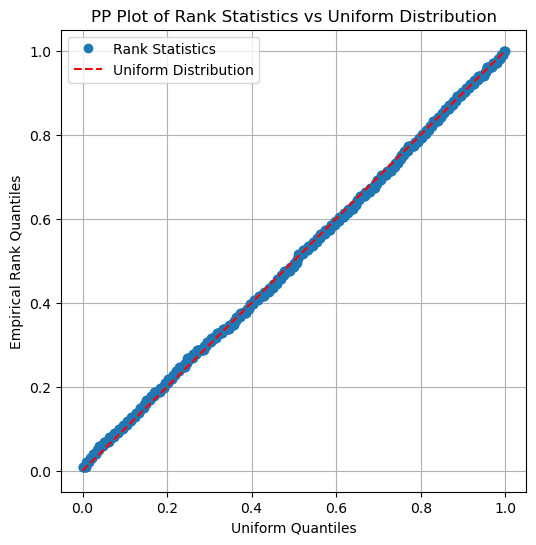

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Function to calculate rank statistics
def calculate_rank_statistics(prior_samples, posterior_samples):
    ranks = []
    for prior_sample, posterior_sample in zip(prior_samples, posterior_samples):
        # Rank of the prior sample within the posterior distribution
        rank = np.sum(posterior_sample < prior_sample) + 1
        ranks.append(rank / (len(posterior_sample) + 1))  # Normalize the rank
    return np.array(ranks)

# Function to create a PP plot comparing rank statistics to a uniform distribution
def pp_plot(ranks, N):
    # Sort the ranks
    sorted_ranks = np.sort(ranks)
    
    # Uniform quantiles
    uniform_quantiles = uniform.ppf(np.linspace(0, 1, N))
    
    # Create PP plot
    plt.figure(figsize=(6, 6))
    plt.plot(uniform_quantiles, sorted_ranks, marker='o', linestyle='none', label='Rank Statistics')
    plt.plot([0, 1], [0, 1], color='r', linestyle='--', label='Uniform Distribution')  # 45-degree line
    
    # Add labels and title
    plt.xlabel('Uniform Quantiles')
    plt.ylabel('Empirical Rank Quantiles')
    plt.title('PP Plot of Rank Statistics vs Uniform Distribution')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
N = 1000  # Number of runs
prior_samples = np.random.normal(0, 1, N)  # Simulate N prior samples
posterior_samples = np.random.normal(0, 1, (N, 100))  # Simulate N sets of posterior samples

# Calculate rank statistics
ranks = calculate_rank_statistics(prior_samples, posterior_samples)

# Generate PP plot
pp_plot(ranks, N)


In [2]:
def coordinate_idx_wrapper(bounded_idxs, periodic_idxs, subset_idxs):
    """
    Organize bounded and periodic coordinates given subset indicies
    NOTE: Assumes increasing index label order
    """
    bounded_coordinates_ = []
    periodic_coordinates_ = []
    j = 0
    for i in subset_idxs:
        if i in bounded_idxs:
            bounded_coordinates_.append(j)
        elif i in periodic_idxs:
            periodic_coordinates_.append(j)
        j += 1
    bounded_coordinates_ = jnp.array(bounded_coordinates_)
    periodic_coordinates_ = jnp.array(periodic_coordinates_)
    return bounded_coordinates_, periodic_coordinates_

def get_subidx_labels(subset_idxs, labels):
    """ 
    Helper method to get labels for cornerplot
    """
    sub_idx_labels = []
    for i in subset_idxs:
        sub_idx_labels.append(labels[i])
    return np.array(sub_idx_labels)

In [3]:
model_base = gwfast_LVGW150914(wf_model=IMRPhenomD, chi=1, eps=0.20, nbins=10)

Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_L_ASD_GW150914.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_H_ASD_GW150914.txt 
fmin:  20.0
fmax:  512.0
df_standard:  49.2
nbins:  10
SNR at true values: 22.96
n_bins = 152
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_L_ASD_GW150914.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_H_ASD_GW150914.txt 


In [4]:
n=10
true_params = model_base._newDrawFromPrior(1, seed=n).squeeze()

true_params = true_params.at[7].set(model_base.true_params[7])

model = gwfast_LVGW150914(wf_model=IMRPhenomD, chi=1, eps=0.20, true_params=true_params, seed=n)

128588 samples obtained from rejection sampling
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_L_ASD_GW150914.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_H_ASD_GW150914.txt 
Manual injection used
fmin:  20.0
fmax:  512.0
df_standard:  0.25
nbins:  1968
SNR at true values: 4.74
n_bins = 152
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_L_ASD_GW150914.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_H_ASD_GW150914.txt 


In [ ]:
true_params

In [9]:
n_particles = 200

subset_params = jnp.array([0, 1, 2, 3, 4, 5, 6, 8, 9, 10])

bounded_coordinates_, periodic_coordinates_ = coordinate_idx_wrapper(model.bounded_coordinates, model.periodic_coordinates, subset_params)

X_injection = jnp.tile(model.true_params, n_particles).reshape(n_particles, model.DoF)

def potential_subset(X_red):
    X_ = X_injection.at[:, subset_params].set(X_red)
    return model.potential(X_)

def gradient_subset(X_red):
    X_ = X_injection.at[:, subset_params].set(X_red)
    grad = model.gradient_potential(X_)
    return grad[:, subset_params]#, hess[:, subset_params[:, None], subset_params]

# Subset definitions needed for run 
n_iter = 40000

eps = 0.5

# Birth death
stride = 100
# rate = eps * 0.01
rate = eps * 0.01
key = jax.random.PRNGKey(42)
X0 = model._newDrawFromPrior(n_particles, seed=n+1)

sigmas = jnp.ones(len(subset_params)) * 1

# NOTE: WE'RE DOING STEPSTONE RIGHT NOW!!!
sam = ula_sampler_full_jax_jit_stepstone(key, 
                               potential_subset, 
                               gradient_subset, 
                               n_iter, 
                               eps, 
                               X0[:, subset_params], 
                               model.lower_bound[subset_params], 
                               model.upper_bound[subset_params], 
                               stride, 
                               rate, 
                               sigmas, 
                               bounded_coordinates_, 
                               periodic_coordinates_)

128914 samples obtained from rejection sampling


/home/al44828/miniconda3/envs/myenv6/lib/python3.11/site-packages/jax/_src/ops/scatter.py:94: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


In [ ]:
sam = ula_sampler_full_jax_jit_stepstone(key, 
                               potential_subset, 
                               gradient_subset, 
                               n_iter, 
                               eps, 
                               sam[-1], 
                               model.lower_bound[subset_params], 
                               model.upper_bound[subset_params], 
                               stride, 
                               rate, 
                               sigmas, 
                               bounded_coordinates_, 
                               periodic_coordinates_)

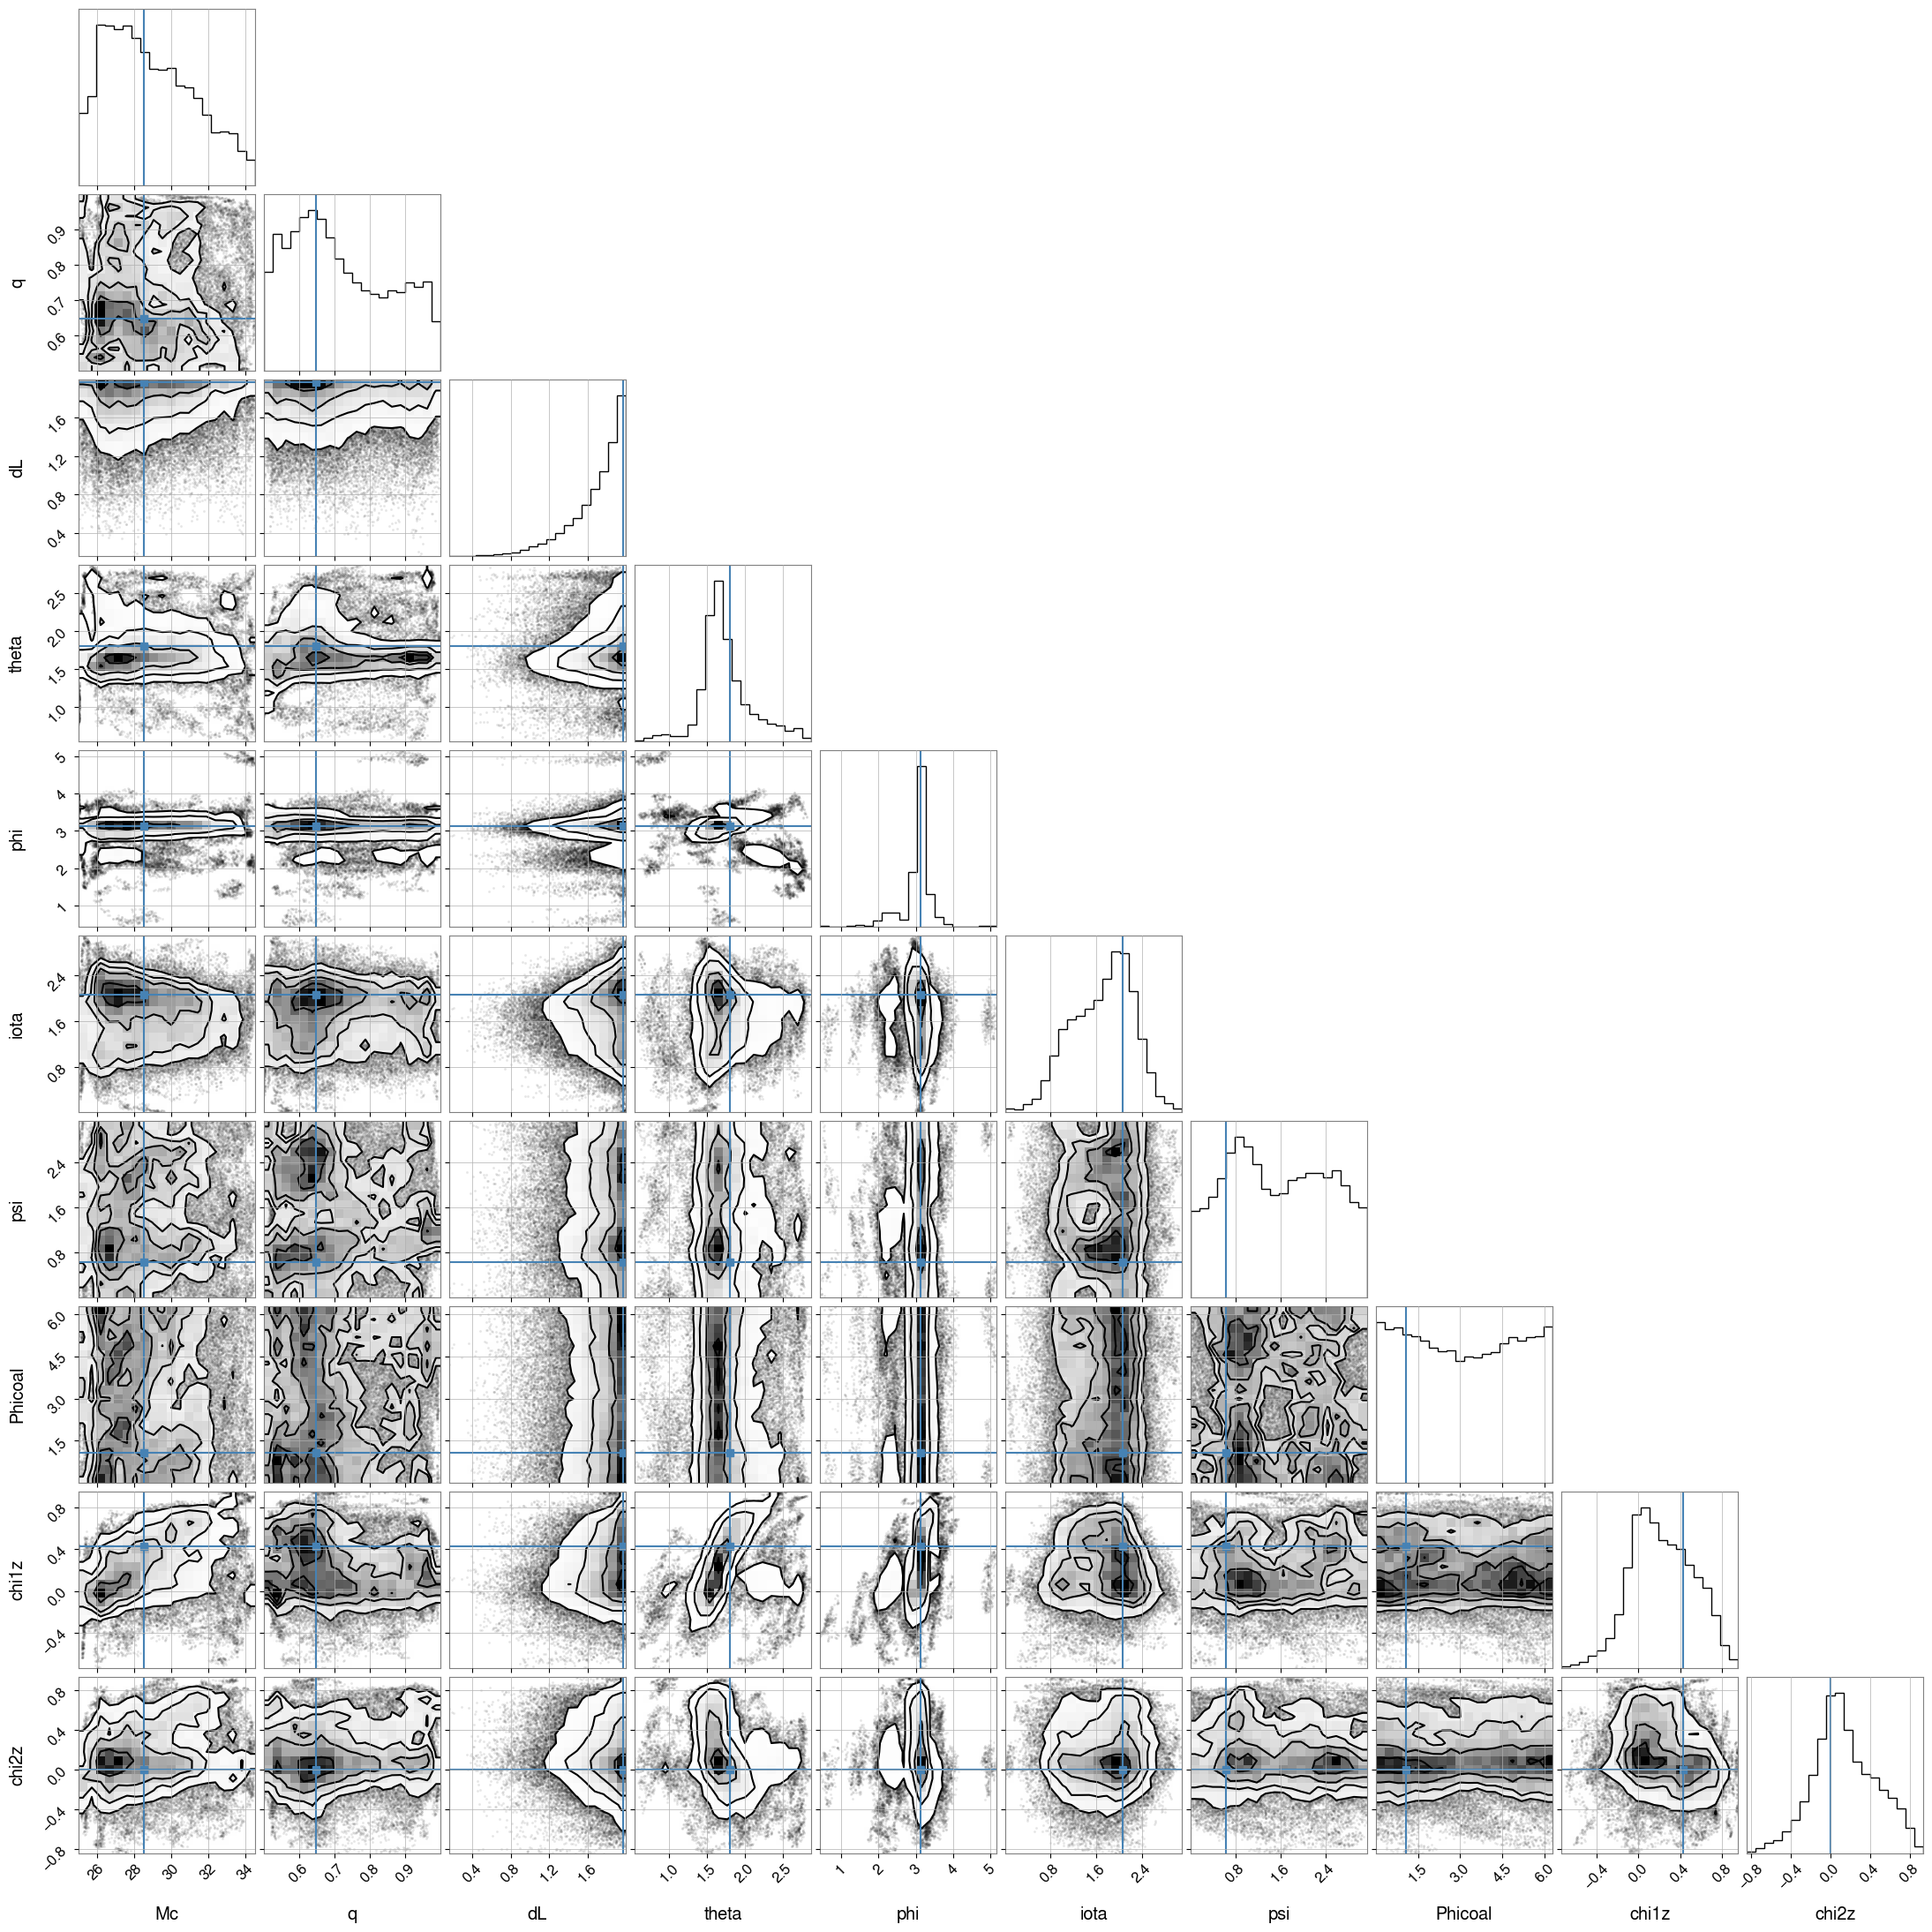

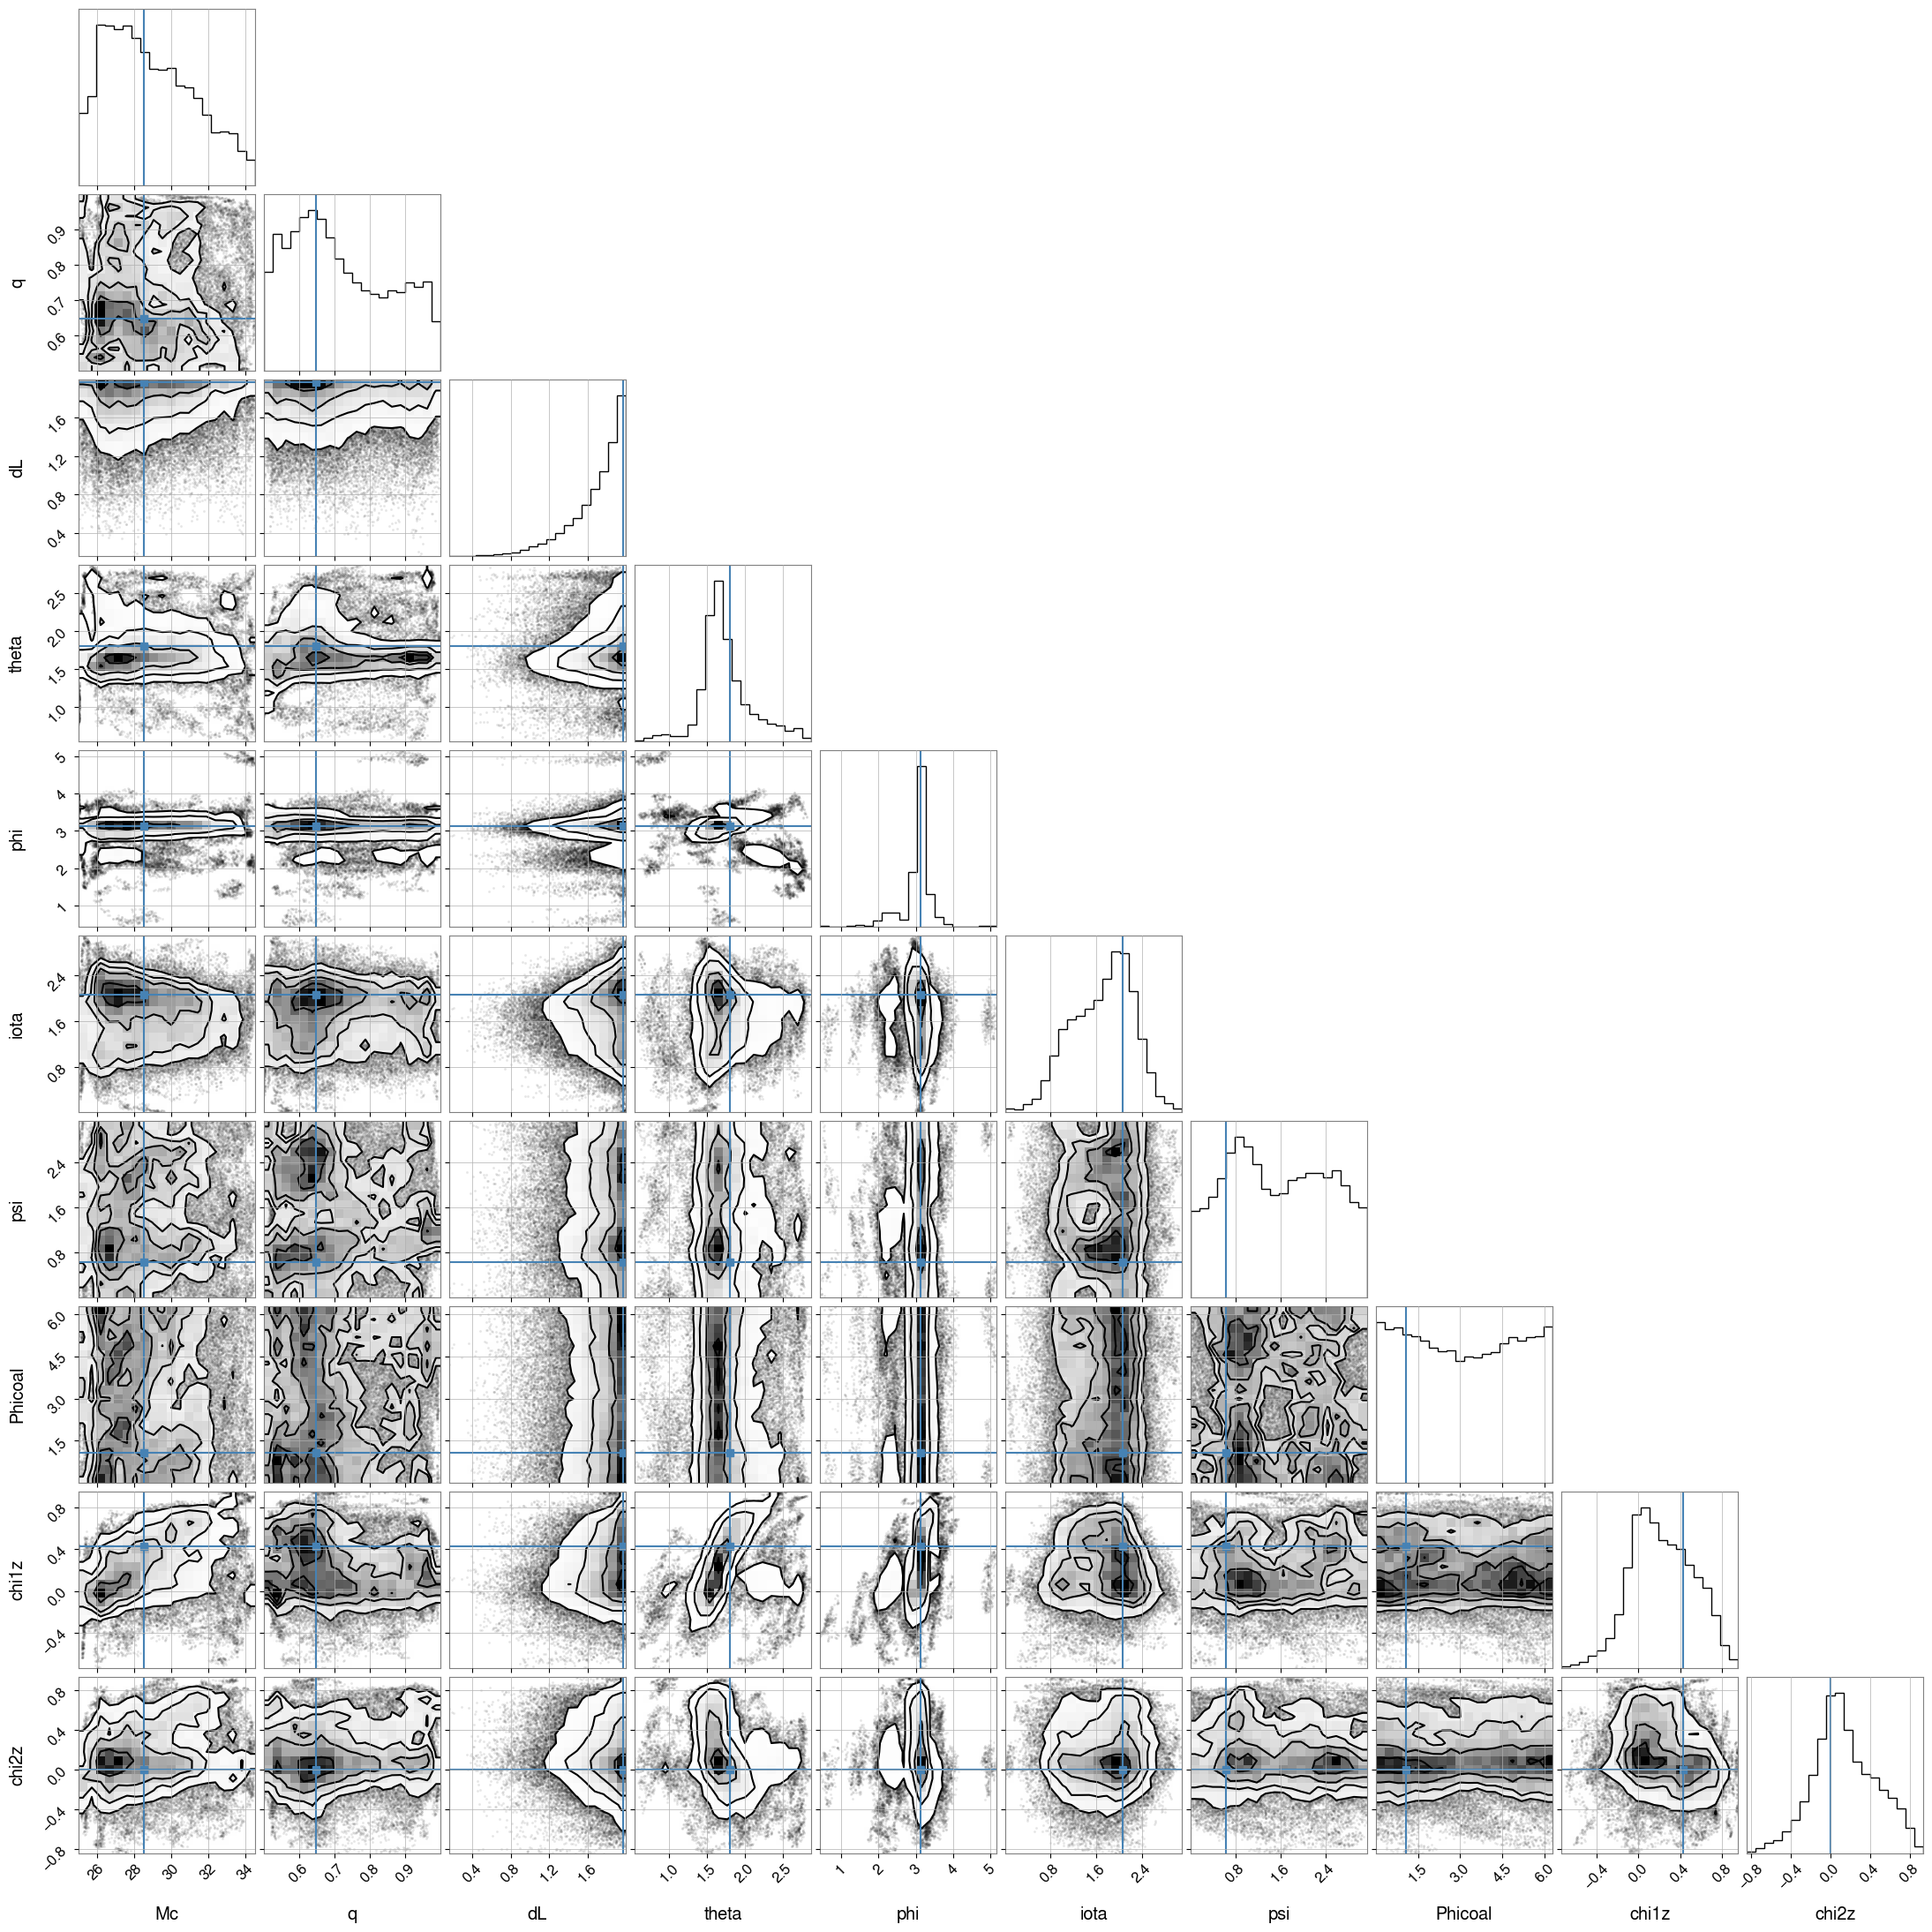

In [10]:
reshaped_matrix = np.array(sam.reshape((sam.shape[0] * sam.shape[1], 10)))
corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=get_subidx_labels(subset_params, model.gwfast_param_order), truths=model.true_params[subset_params])
# fig = corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=model.gwfast_param_order[subset_params], truths=true, color='r')

In [ ]:
model.true_params[subset_params]

In [ ]:
model_base = gwfast_LVGW150914(wf_model=IMRPhenomD, nbins=10) # For bounds and draw

n_runs = 2

output_dict = {}

save_dir = os.path.join

for n in range(n_runs):
    true_params = model_base._newDrawFromPrior(1).squeeze()
    model = gwfast_LVGW150914(wf_model=IMRPhenomD, nbins=100, true_params=true_params, seed=n)
    X0 = model_base._newDrawFromPrior(n_particles)
    key = jax.random.PRNGKey(n)
    sam = ula_sampler_full_jax_jit_stepstone(key, model.potential, model.gradient_potential, n_iter, eps, X0, model.lower_bound, model.upper_bound, stride, rate, sigmas, model.bounded_coordinates, model.periodic_coordinates)

    metadata = {}
    # metadata['inj_params'] = np.array(true_params)
    # metadata['output_samples'] = np.array(sam)
    # metadata['h_true'] = np.array(model.htrue, dtype='complex128')
    # metadata['noise'] = np.array(model.noise, dtype='complex128')
    # metadata['data'] = np.array(model.data, dtype='complex128')

    iter_string = f"{n:03d}" 

    output_dict[iter_string] = metadata

    reshaped_matrix = np.array(sam.reshape((sam.shape[0] * sam.shape[1], 11)))
    reshaped_matrix[:, 7] -= true_params[7]
    
    true = true_params.at[7].add(-true_params[7]) # shift tc
    fig = corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=model.gwfast_param_order, truths=true, color='r')


    fig.savefig('outdir_pp/%s.png' % iter_string)

    np.save('outdir_pp/%s.npy' % iter_string, reshaped_matrix[-50000])
    # dd.io.save('outdir_pp/%s.h5' % iter_string, metadata)
    


In [ ]:
metadata.keys()

In [ ]:
metadata['data'].dtype

In [ ]:
dd.io.save('outdir_pp/%s.h5' % iter_string, metadata)

In [ ]:
metadata

In [ ]:
plt.loglog(model.fgrid, model.data['L1'].squeeze())

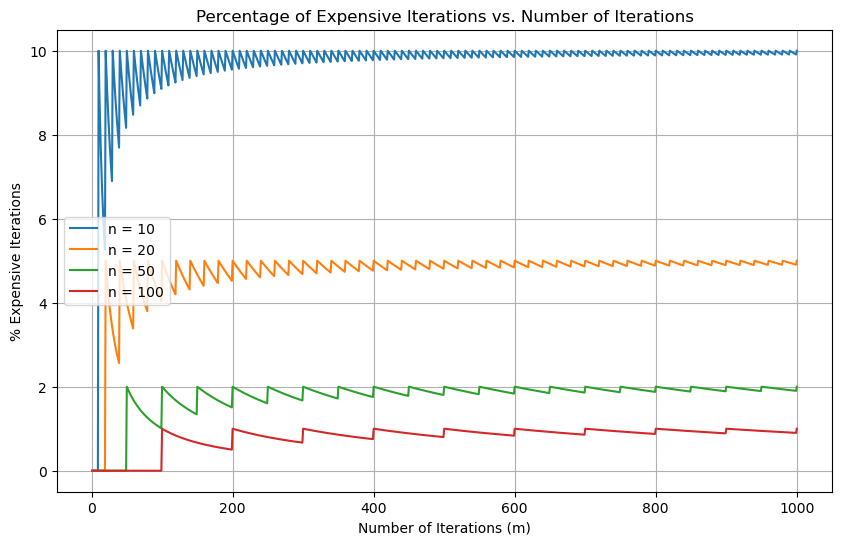

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate percentage of expensive iterations
def expensive_iteration_percentage(m, n):
    return (m // n) / m * 100

# Parameters
n_values = [10, 20, 50, 100]  # Different stride values
m_values = np.arange(1, 1001)  # Total iterations from 1 to 1000

# Plot the percentage for each stride value
plt.figure(figsize=(10, 6))

for n in n_values:
    percentages = [expensive_iteration_percentage(m, n) for m in m_values]
    plt.plot(m_values, percentages, label=f'n = {n}')


# Add labels and title
plt.xlabel('Number of Iterations (m)')
plt.ylabel('% Expensive Iterations')
plt.title('Percentage of Expensive Iterations vs. Number of Iterations')
plt.legend()
plt.grid(True)
plt.show()
